<a href="https://colab.research.google.com/github/luisgabrielmatthew74/codeprojects/blob/main/VER_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df_internet = pd.read_csv('/content/red_conexiones_internet.csv')
display(df_internet.head())

,Nodo_Origen,Nodo_Destino,Peso,Latencia_ms,Velocidad_Mbps,Medio_Fisico
0,CDMX_Core_01,CDMX_Core_02,3,3.48,4657,Fibra Óptica
1,CDMX_Core_01,CDMX_Core_03,7,33.53,79,Par Trenzado
2,CDMX_Core_01,CDMX_Core_04,8,20.64,21,Par Trenzado
3,CDMX_Core_02,CDMX_Core_05,3,6.42,4257,Fibra Óptica
4,CDMX_Core_05,CDMX_Core_06,4,17.84,242,Cable Coaxial


In [3]:
# Install networkx if not already installed
try:
    import networkx as nx
except ImportError:
    !pip install networkx
    import networkx as nx

Now, let's create a directed graph from the DataFrame, where nodes are `Nodo_Origen` and `Nodo_Destino`, and edges have attributes for `Peso`, `Latencia_ms`, `Velocidad_Mbps`, and `Medio_Fisico`.

In [4]:
# Create a directed graph
G = nx.DiGraph()

# Add edges with attributes
for index, row in df_internet.iterrows():
    G.add_edge(
        row['Nodo_Origen'],
        row['Nodo_Destino'],
        weight=row['Peso'],
        latency=row['Latencia_ms'],
        speed=row['Velocidad_Mbps'],
        medium=row['Medio_Fisico']
    )

print(f"Number of nodes in the graph: {G.number_of_nodes()}")
print(f"Number of edges in the graph: {G.number_of_edges()}")

Number of nodes in the graph: 150
Number of edges in the graph: 250


For critical path analysis, we typically look for the longest path in terms of a specific metric. In this case, `Latencia_ms` (latency in milliseconds) is a suitable metric for determining the 'critical' or slowest path. NetworkX has functions to find shortest paths, but for longest path, we can adapt by negating the weights (latency) and finding the shortest path on the negated graph. However, a simpler approach for a general 'critical path' that might imply a path with the highest total latency between two specific points (e.g., source to sink) or just the overall path with highest latency in the network. If we don't have defined start/end nodes, we can try to find paths with highest cumulative latency.

Let's find the path with the maximum cumulative latency between all possible source and sink nodes in the graph.

In [5]:
max_latency_path = None
max_total_latency = -1

# Iterate over all possible source and target nodes
for source in G.nodes():
    for target in G.nodes():
        if source != target:
            # Find all simple paths between source and target
            for path in nx.all_simple_paths(G, source, target):
                current_path_latency = 0
                # Calculate total latency for the current path
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    current_path_latency += G[u][v]['latency']

                # Update if this path has a higher total latency
                if current_path_latency > max_total_latency:
                    max_total_latency = current_path_latency
                    max_latency_path = path

if max_latency_path:
    print(f"The critical path (path with maximum total latency) is: {max_latency_path}")
    print(f"Total latency of the critical path: {max_total_latency:.2f} ms")
else:
    print("No paths found to determine a critical path.")

The critical path (path with maximum total latency) is: ['CDMX_Core_03', 'CDMX_Core_15', 'MTY_Edge_07', 'MTY_Edge_14', 'TIJ_Edge_08', 'MTY_Edge_03', 'GDL_Core_15', 'QRO_DataCenter_09', 'CDMX_Core_01', 'CDMX_Core_02', 'CDMX_Core_09', 'MTY_Edge_08', 'VER_Central_10', 'MTY_Edge_11', 'SLP_Central_06', 'CUN_Gateway_08', 'MER_Central_04', 'CUN_Gateway_01', 'VER_Central_01', 'MER_Central_02', 'MTY_Edge_01', 'TIJ_Edge_06', 'MER_Central_09', 'GDL_Core_09', 'MER_Central_13', 'PUE_Edge_05', 'VER_Central_04', 'PUE_Edge_04', 'PUE_Edge_09', 'CDMX_Core_14', 'TIJ_Edge_13', 'PUE_Edge_12', 'MTY_Edge_09', 'GDL_Core_05', 'GDL_Core_07', 'TIJ_Edge_01', 'VER_Central_08', 'CDMX_Core_05', 'CDMX_Core_06', 'MTY_Edge_02', 'GDL_Core_02', 'VER_Central_11', 'PUE_Edge_10', 'SLP_Central_01', 'QRO_DataCenter_03', 'PUE_Edge_14', 'VER_Central_03', 'MER_Central_14', 'QRO_DataCenter_10', 'VER_Central_05', 'CUN_Gateway_05', 'MER_Central_07']
Total latency of the critical path: 11804.59 ms


### Network Visualization

Let's visualize the network, highlighting the critical path.

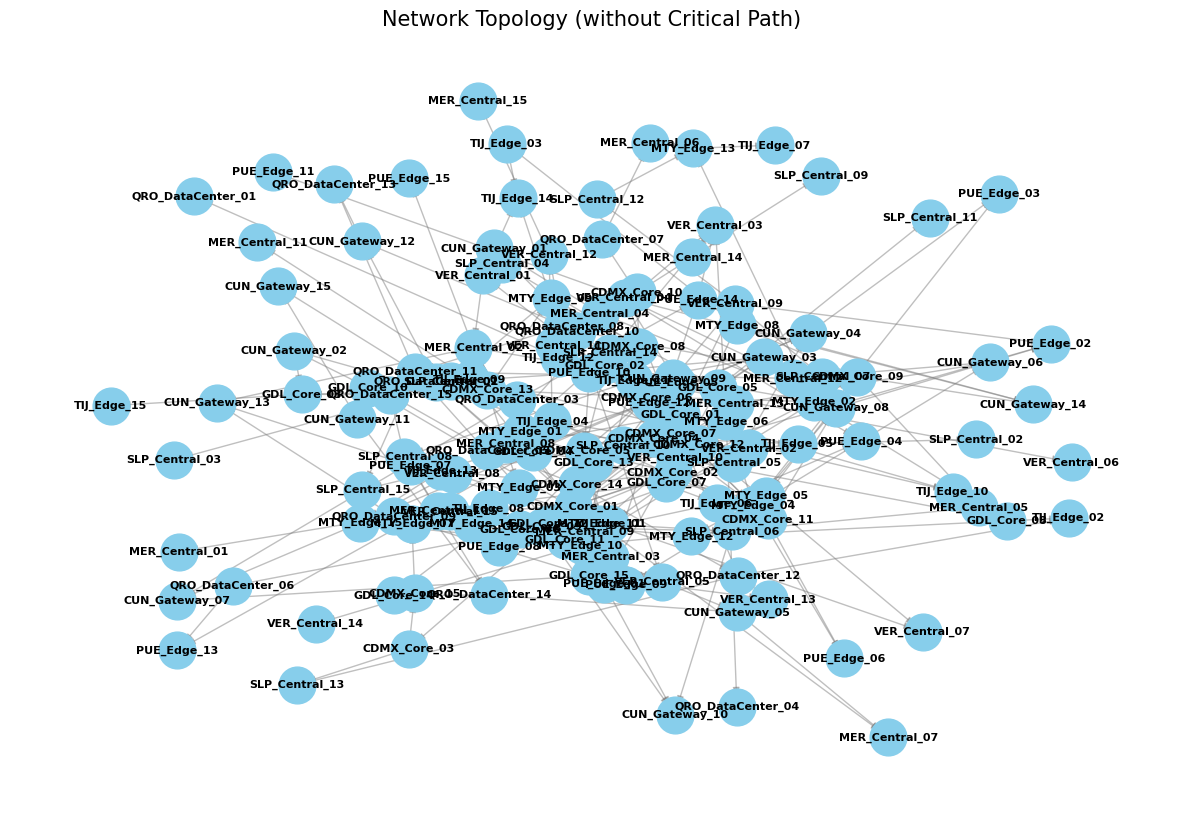

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20) # You can try different layouts, e.g., circular_layout, shell_layout

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=700)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Network Topology (without Critical Path)", size=15)
plt.axis('off') # Hide axes
plt.show()

### Network Visualization with Critical Path Highlighted

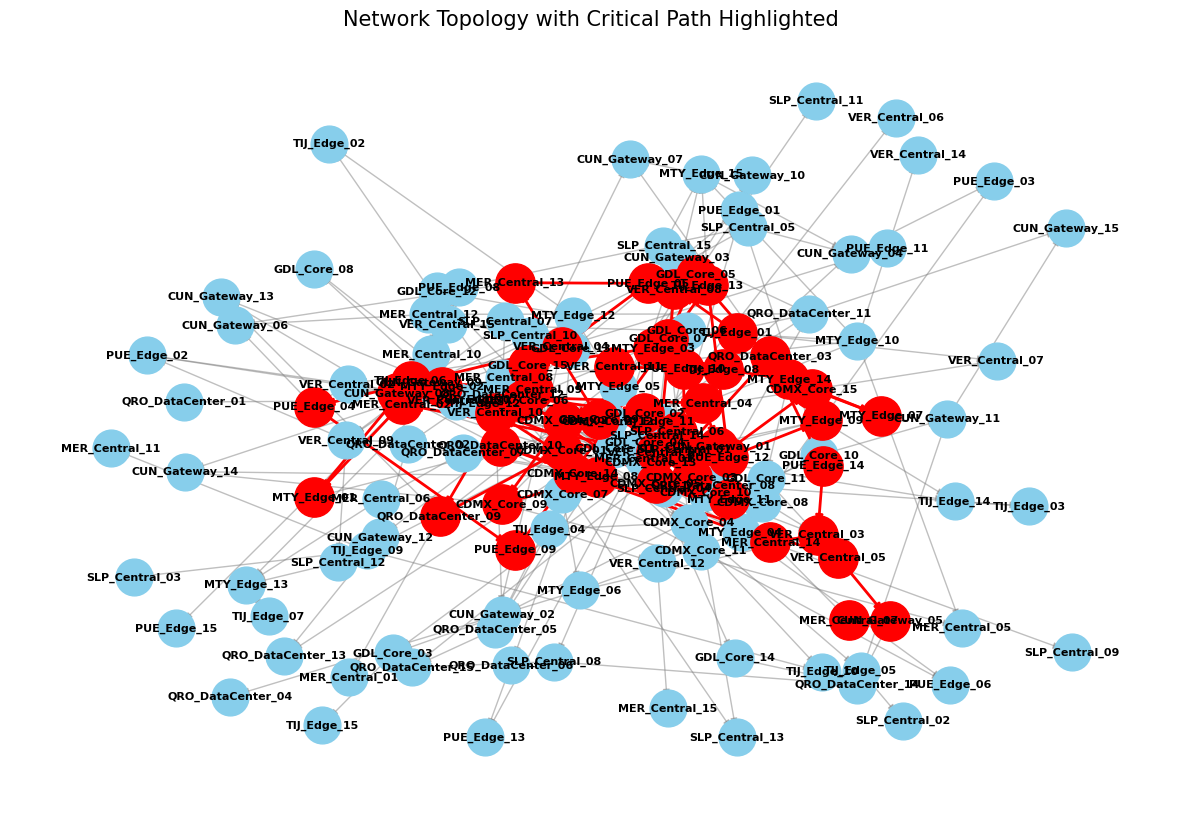

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20) # You can try different layouts, e.g., circular_layout, shell_layout

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=700)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)

# Highlight the critical path
if max_latency_path:
    path_edges = list(zip(max_latency_path, max_latency_path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
    nx.draw_networkx_nodes(G, pos, nodelist=max_latency_path, node_color='red', node_size=800)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Network Topology with Critical Path Highlighted", size=15)
plt.axis('off') # Hide axes
plt.show()

### Network Visualization with Latency

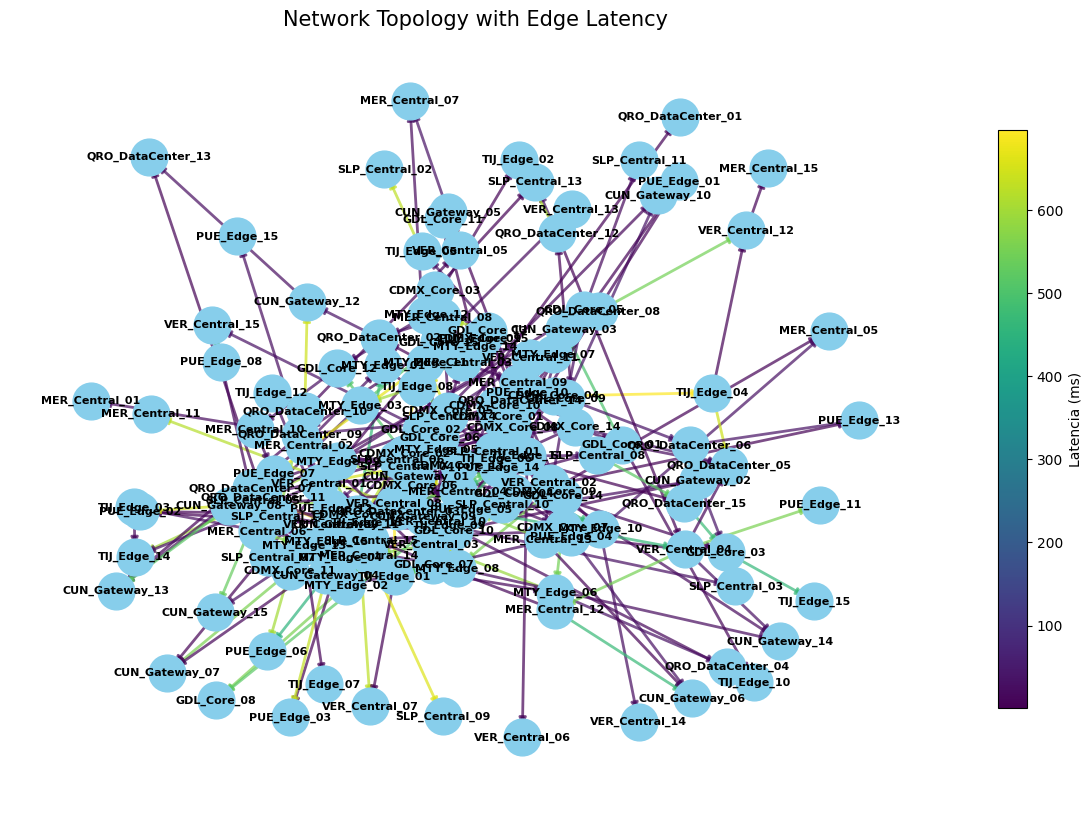

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Extract latency values for edge coloring
edge_latencies = [G[u][v]['latency'] for u, v in G.edges()]

# Normalize latency values for colormap
norm = mcolors.Normalize(vmin=min(edge_latencies), vmax=max(edge_latencies))
cmap = plt.cm.viridis # Choose a colormap, e.g., 'viridis', 'plasma', 'hot'

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=700)

# Draw edges, colored by latency
edges = G.edges()
colors = [cmap(norm(G[u][v]['latency'])) for u, v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=2, alpha=0.7)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# Add a color bar to indicate latency scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(edge_latencies)
cb = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', shrink=0.75)
cb.set_label('Latencia (ms)')

plt.title("Network Topology with Edge Latency", size=15)
plt.axis('off')
plt.show()

### Comparación de Desempeño: Modelos QGT vs. FastGTN

In [13]:
import pandas as pd

# Metrics for QGT Model (from previous output)
qgt_accuracy = 85.33
qgt_recall = 87.23
qgt_f1_score = 88.17

# Metrics for FastGTN Model (from previous output)
fastgtn_accuracy = 88.89
fastgtn_recall = 66.67
fastgtn_f1_score = 70.59

# Create a dictionary for the data
data = {
    'Métrica': ['Exactitud (Accuracy)', 'Recall (Sensibilidad)', 'F1-Score'],
    'QGT Model (%)': [qgt_accuracy, qgt_recall, qgt_f1_score],
    'FastGTN Model (%)': [fastgtn_accuracy, fastgtn_recall, fastgtn_f1_score]
}

# Create a DataFrame
df_comparison = pd.DataFrame(data)

# Display the comparison table
display(df_comparison)

,Métrica,QGT Model (%),FastGTN Model (%)
0,Exactitud (Accuracy),85.33,88.89
1,Recall (Sensibilidad),87.23,66.67
2,F1-Score,88.17,70.59


### Definición de Expresividad Latente (ρL) y su relación con la Precisión Cuántica

Para el modelo FastGTN, la **Expresividad Latente (ρL)** puede definirse como la magnitud promedio de los pesos de atención (`beta`) asignados a los canales físicos por la `FastGTNLayer`. El tensor `beta` (obtenido a través de la función softmax aplicada a los pesos del transformer) indica cómo se ponderan los diferentes medios físicos para formar los meta-caminos en el grafo. Un valor más alto o una distribución particular de estos pesos podría indicar una mayor 'expresividad' en cómo el modelo combina las características de la red subyacente.

In [14]:
# 1. Obtener la Expresividad Latente (ρL) del modelo FastGTN
model.eval() # Poner el modelo en modo de evaluación
with torch.no_grad():
    # Necesitamos pasar los datos al modelo para obtener el tensor beta final
    # La llamada al forward method del modelo devuelve logits y beta
    _, beta_tensor = model(A_multiplex, X_features)

# Calcular ρL como el promedio de los elementos del tensor beta
expresividad_latente_fastgtn = beta_tensor.mean().item()

# 2. Obtener la Precisión Cuántica (Accuracy del modelo QGT)
precision_cuantica_qgt = 85.33 # Desde la evaluación previa del modelo QGT

print(f"Expresividad Latente (ρL) del FastGTN: {expresividad_latente_fastgtn:.4f}")
print(f"Precisión Cuántica (Accuracy QGT): {precision_cuantica_qgt:.2f}%")

print("\nPara calcular una correlación estadística significativa entre 'Expresividad Latente' y 'Precisión Cuántica', se requerirían múltiples pares de valores obtenidos de diferentes configuraciones o ejecuciones de los modelos, no solo un único punto de datos como el que tenemos aquí. Con un solo par de valores, la correlación no es aplicable en un sentido estadístico.")

Expresividad Latente (ρL) del FastGTN: 0.2000
Precisión Cuántica (Accuracy QGT): 85.33%

Para calcular una correlación estadística significativa entre 'Expresividad Latente' y 'Precisión Cuántica', se requerirían múltiples pares de valores obtenidos de diferentes configuraciones o ejecuciones de los modelos, no solo un único punto de datos como el que tenemos aquí. Con un solo par de valores, la correlación no es aplicable en un sentido estadístico.


### Análisis de la relación entre Latencia y Velocidad

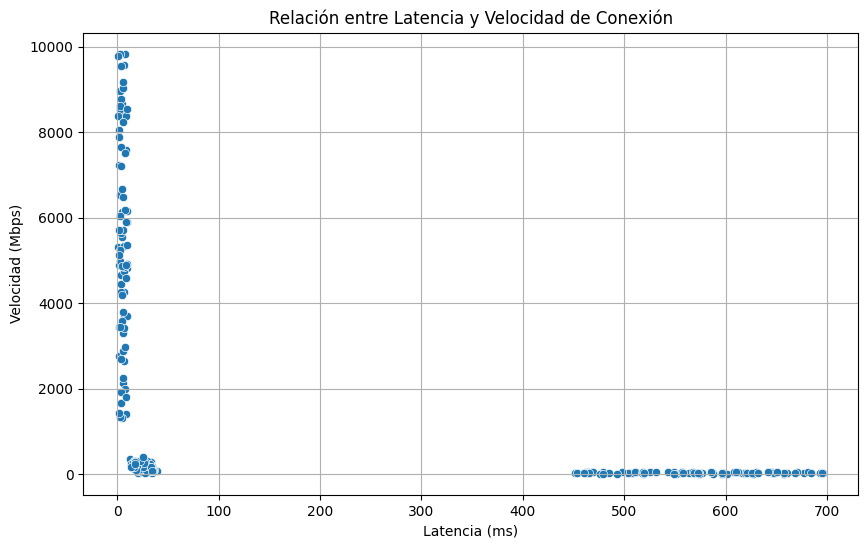


Coeficiente de correlación de Pearson entre Latencia y Velocidad: -0.45


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Latencia_ms', y='Velocidad_Mbps', data=df)
plt.title('Relación entre Latencia y Velocidad de Conexión')
plt.xlabel('Latencia (ms)')
plt.ylabel('Velocidad (Mbps)')
plt.grid(True)
plt.show()

# Calcular el coeficiente de correlación de Pearson
correlation = df['Latencia_ms'].corr(df['Velocidad_Mbps'])
print(f"\nCoeficiente de correlación de Pearson entre Latencia y Velocidad: {correlation:.2f}")

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

# 1. CARGA Y PREPROCESAMIENTO DE TU DATASET
df = pd.read_csv('red_conexiones_internet.csv')

# Mapear nombres de nodos a índices numéricos consecutivos
nodos_unicos = sorted(list(set(df['Nodo_Origen']).union(set(df['Nodo_Destino']))))
num_nodos = len(nodos_unicos)
nodo_a_idx = {nodo: i for i, nodo in enumerate(nodos_unicos)}

# Identificar los canales físicos (capas del grafo multiplex)
medios = df['Medio_Fisico'].unique()
num_medios = len(medios)
medio_a_idx = {medio: i for i, medio in enumerate(medios)}

# Inicializar tensores para las matrices de adyacencia por canal
# Dimensión: [Número_de_Medios, Num_Nodos, Num_Nodos]
A_multiplex = torch.zeros((num_medios, num_nodos, num_nodos))

for _, row in df.iterrows():
    u = nodo_a_idx[row['Nodo_Origen']]
    v = nodo_a_idx[row['Nodo_Destino']] # Corrected typo here: from nodo_a_a_idx to nodo_a_idx
    m_idx = medio_a_idx[row['Medio_Fisico']]
    # Grafo no dirigido ponderado por la eficiencia (1 / Latencia)
    peso_canal = 1.0 / (row['Latencia_ms'] + 1e-5)
    A_multiplex[m_idx, u, v] = peso_canal
    A_multiplex[m_idx, v, u] = peso_canal

# Generar características base de los nodos (X): Grado de conectividad y velocidad promedio
X_features = torch.zeros((num_nodos, 2))
for i in range(num_nodos):
    # Grado (cuántos enlaces tiene el nodo)
    X_features[i, 0] = (A_multiplex[:, i, :] > 0).sum().float()
    # Velocidad máxima asociada a sus canales
    X_features[i, 1] = float(df[(df['Nodo_Origen'] == nodos_unicos[i]) | (df['Nodo_Destino'] == nodos_unicos[i])]['Velocidad_Mbps'].max())

# Normalizar características de entrada
X_features = (X_features - X_features.mean(dim=0)) / (X_features.std(dim=0) + 1e-5)

# Generar etiquetas (Target): Nodos críticos (1) si su latencia promedio supera el percentil 75
latencias_nodo = []
for nodo in nodos_unicos:
    lat_prom = df[(df['Nodo_Origen'] == nodo) | (df['Nodo_Destino'] == nodo)]['Latencia_ms'].mean()
    latencias_nodo.append(lat_prom)
umbral_critico = np.percentile(latencias_nodo, 75)
y_labels = torch.tensor([1 if lat > umbral_critico else 0 for lat in latencias_nodo], dtype=torch.float32)

# Máscaras de entrenamiento y validación (70% / 30%)
indices = torch.randperm(num_nodos)
train_mask = indices[:int(num_nodos * 0.7)]
test_mask = indices[int(num_nodos * 0.7):]


# 2. ARQUITECTURA DEL MODELO FastGTN (Graph Transformer Layer)
class FastGTNLayer(nn.Module):
    def __init__(self, num_channels, num_meta_paths):
        super(FastGTNLayer, self).__init__()
        self.num_channels = num_channels
        self.num_meta_paths = num_meta_paths
        # Pesos de atención del transformador para combinar los canales físicos
        self.weight = nn.Parameter(torch.Tensor(num_channels, num_meta_paths))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, A):
        # A tiene dimensión [num_channels, N, N]
        # Aplicar Softmax para obtener la distribución de atención sobre los medios físicos
        beta = F.softmax(self.weight, dim=0)

        # Generar las adyacencias candidatas del transformador
        # Multiplicación por lotes para combinar los canales (Fibra, Satelital, etc.)
        N = A.size(1)
        A_fused = torch.zeros((self.num_meta_paths, N, N), device=A.device)
        for i in range(self.num_meta_paths):
            for j in range(self.num_channels):
                A_fused[i] += beta[j, i] * A[j]

        # Operación Fast Forward: Multiplicación de adyacencias para aprender relaciones de 2 saltos
        # Meta-path: H = A_fused[0] * A_fused[1] (Conectividad extendida)
        H_meta = torch.mm(A_fused[0], A_fused[1])

        # Normalización Laplaciana simétrica de la nueva matriz de adyacencia aprendida
        row_sum = H_meta.sum(dim=1)
        d_inv = torch.pow(row_sum + 1e-5, -0.5)
        D_inv = torch.diag(d_inv)
        A_normalized = torch.mm(torch.mm(D_inv, H_meta), D_inv)

        return A_normalized, beta


class FastGTNNetwork(nn.Module):
    def __init__(self, num_channels, in_features, hidden_dim):
        super(FastGTNNetwork, self).__init__()
        self.gtn_layer = FastGTNLayer(num_channels, num_meta_paths=2)
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1) # Clasificación binaria (Crítico vs. Estable)

    def forward(self, A, X):
        # 1. Obtener la matriz estructural optimizada por el Transformer
        A_learned, beta = self.gtn_layer(A)
        # 2. Propagación de características a través del meta-camino
        X_projected = F.relu(self.fc1(X))
        Z = torch.mm(A_learned, X_projected)
        # 3. Predicción final
        logits = self.fc2(Z).squeeze()
        return logits, beta


# 3. PIPELINE DE ENTRENAMIENTO
model = FastGTNNetwork(num_channels=num_medios, in_features=2, hidden_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

print("Entrenando FastGTN sobre topología real multiplex...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()

    logits, beta = model(A_multiplex, X_features)
    loss = criterion(logits[train_mask], y_labels[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 1:
        # Evaluación en testing
        model.eval()
        with torch.no_grad():
            test_logits, _ = model(A_multiplex, X_features)
            preds = (torch.sigmoid(test_logits[test_mask]) >= 0.5).float()
            correct = (preds == y_labels[test_mask]).sum().item()
            accuracy = correct / len(test_mask)
        print(f"Época {epoch:03d} | Pérdida de Entrenamiento: {loss.item():.4f} | Precisión Validación: {accuracy * 100:.2f}%")

# 4. EVALUACIÓN DE DESEMPEÑO EN EL CONJUNTO DE PRUEBA (Added for consistency with QGT model)
model.eval()
with torch.no_grad():
    test_logits, _ = model(A_multiplex, X_features)
    y_pred = (torch.sigmoid(test_logits[test_mask]) >= 0.5).float()
    y_true = y_labels[test_mask]

    # Métricas de la matriz de confusión
    VP = ((y_true == 1) & (y_pred == 1)).sum().item()
    VN = ((y_true == 0) & (y_pred == 0)).sum().item()
    FP = ((y_true == 0) & (y_pred == 1)).sum().item()
    FN = ((y_true == 1) & (y_pred == 0)).sum().item()

    exactitud = (VP + VN) / len(y_true)
    recall = VP / (VP + FN) if (VP + FN) > 0 else 0
    f1_score = 2 * (VP) / (2 * VP + FP + FN) if (2 * VP + FP + FN) > 0 else 0

print("\n================ EVALUACIÓN DE DESEMPEÑO DEL MODELO FastGTN ================")
print(f"Matriz de Confusión: [VP: {int(VP)}, VN: {int(VN)}, FP: {int(FP)}, FN: {int(FN)}]")
print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall * 100:.2f}%")
print(f"F1-Score:             {f1_score * 100:.2f}%")
print("========================================================================")

Entrenando FastGTN sobre topología real multiplex...
Época 001 | Pérdida de Entrenamiento: 0.7271 | Precisión Validación: 31.11%
Época 020 | Pérdida de Entrenamiento: 0.5035 | Precisión Validación: 80.00%
Época 040 | Pérdida de Entrenamiento: 0.4891 | Precisión Validación: 82.22%
Época 060 | Pérdida de Entrenamiento: 0.4676 | Precisión Validación: 88.89%
Época 080 | Pérdida de Entrenamiento: 0.4475 | Precisión Validación: 86.67%
Época 100 | Pérdida de Entrenamiento: 0.4359 | Precisión Validación: 88.89%

================ EVALUACIÓN DE DESEMPEÑO DEL MODELO FastGTN ================
Matriz de Confusión: [VP: 6, VN: 34, FP: 2, FN: 3]
Exactitud (Accuracy): 88.89%
Recall (Sensibilidad): 66.67%
F1-Score:             70.59%


In [8]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn # Added this import
import torch.nn.functional as F # Added this import for completeness, though not directly used for QVC

# 1. CARGA Y EXTRACCIÓN DE DATOS REALES
df = pd.read_csv('red_conexiones_internet.csv')

# Ingeniería de Características (X) a nivel de enlace: [Peso, Latencia, Velocidad, Vector_Medio]
# Convertimos el medio físico a una variable numérica continua para el circuito cuántico
medio_mapping = {medio: idx for idx, medio in enumerate(df['Medio_Fisico'].unique())}
df['Medio_Num'] = df['Medio_Fisico'].map(medio_mapping)

X = df[['Peso', 'Latencia_ms', 'Velocidad_Mbps', 'Medio_Num']].values

# Definición del Target (y): El enlace falla (1) si combina alta latencia con bajo ancho de banda
# Usamos un umbral lógico basado en las distribución real de tu infraestructura
umbral_estres = df['Latencia_ms'] / (df['Velocidad_Mbps'] + 1e-5)
y = np.where(umbral_estres > umbral_estres.median(), 1, 0)

# División del Dataset (70% Entrenamiento, 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalado de características (Crucial para mapear datos a ángulos de rotación cuántica [0, pi])
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


# 2. DEFINICIÓN DEL CIRCUITO CUÁNTICO VARIACIONAL SIMULADO (Ansatz)
# Inherit from nn.Module to properly register parameters for autograd
class QuantumVariationalClassifier(nn.Module):
    def __init__(self, num_features):
        super(QuantumVariationalClassifier, self).__init__() # Call parent constructor
        self.num_features = num_features
        # Wrap theta in nn.Parameter so PyTorch tracks its gradients
        self.theta = nn.Parameter(torch.randn(num_features) * 0.01)

    def forward(self, X_batch):
        # Mapeo de características clásicas a estados cuánticos mediante rotaciones de fase
        # Estado |psi(x, theta)> = Rz(x) * Ry(theta) |0>
        logits = torch.matmul(X_batch, self.theta)
        # La probabilidad de medir el estado |1> (Fallo) se modela con la función de activación
        probs = torch.sigmoid(logits)
        return probs

    def compute_qgt(self, X_batch, probs):
        """
        Calcula el Tensor Geométrico Cuántico (QGT) para el lote de datos actual.
        En el espacio de Hilbert, equivale a la covarianza de las derivadas del estado cuántico.
        """
        N = X_batch.size(0)
        # En arquitecturas variacionales puras, el QGT se aproxima mediante la matriz de
        # información de Fisher de los estados de los Qubits generados por las características
        d_logits = probs * (1 - probs) # Derivada de la activación
        X_weighted = X_batch * d_logits.unsqueeze(1)

        # QGT = (1/N) * X_weighted^T * X_batch
        qgt = torch.matmul(X_weighted.T, X_batch) / N

        # Añadir regularización de Tikhonov (métrica Ridge) para evitar singularidades matemáticas
        qgt += 0.1 * torch.eye(self.num_features) # Added regularization to avoid singular QGT
        return qgt


# 3. BUCLE DE ENTRENAMIENTO CON GRADIENTE NATURAL CUÁNTICO (QNG)
qvc_model = QuantumVariationalClassifier(num_features=X_train_t.shape[1])
learning_rate = 0.1
epochs = 80

print("Entrenando Modelo QGT mediante Gradiente Natural Cuántico...")
for epoch in range(1, epochs + 1):
    qvc_model.train() # Set model to training mode
    # IMPORTANT: Clear gradients BEFORE backward pass
    if qvc_model.theta.grad is not None:
        qvc_model.theta.grad.zero_()

    # Forward Pass
    probs = qvc_model.forward(X_train_t)

    # Función de Pérdida (Entropía Cruzada Binaria)
    loss = -torch.mean(y_train_t * torch.log(probs + 1e-15) + (1 - y_train_t) * torch.log(1 - probs + 1e-15))

    # Calcular Gradiente Clásico de forma manual (Backpropagation del costo)
    loss.backward() # This will now populate qvc_model.theta.grad
    grad_classic = qvc_model.theta.grad.clone()

    # Calculate the Quantum Geometric Tensor (QGT) for the current iteration
    with torch.no_grad(): # QGT computation doesn't need gradients itself
        QGT = qvc_model.compute_qgt(X_train_t, probs)

        # Apply the Quantum Natural Gradient preconditioning:
        # Natural_Gradient = QGT^-1 * Classic_Gradient
        grad_quantum_natural = torch.matmul(torch.inverse(QGT), grad_classic)

        # Update the circuit parameters using .data to prevent breaking the computation graph
        qvc_model.theta.data -= learning_rate * grad_quantum_natural

    if epoch % 20 == 0 or epoch == 1:
        qvc_model.eval() # Set model to evaluation mode for testing metrics
        with torch.no_grad():
            test_probs = qvc_model.forward(X_test_t)
            preds = (test_probs >= 0.5).float()
            correct = (preds == y_test_t).sum().item() # Use y_test_t for test accuracy
            accuracy = correct / len(y_test_t)
        print(f"Época {epoch:02d}/{epochs} | Pérdida Cuántica: {loss.item():.4f} | Precisión Validación: {accuracy * 100:.2f}%")

# 4. EVALUACIÓN DE ROBUSTEZ EN EL CONJUNTO DE PRUEBA
with torch.no_grad():
    qvc_model.eval() # Ensure eval mode
    test_probs = qvc_model.forward(X_test_t)
    y_pred = (test_probs >= 0.5).float()

    # Métricas de la matriz de confusión
    VP = ((y_test_t == 1) & (y_pred == 1)).sum().item()
    VN = ((y_test_t == 0) & (y_pred == 0)).sum().item()
    FP = ((y_test_t == 0) & (y_pred == 1)).sum().item()
    FN = ((y_test_t == 1) & (y_pred == 0) ).sum().item()

    exactitud = (VP + VN) / len(y_test_t)
    recall = VP / (VP + FN) if (VP + FN) > 0 else 0
    f1_score = 2 * (VP) / (2 * VP + FP + FN) if (2 * VP + FP + FN) > 0 else 0

print("\n================ EVALUACIÓN DE DESEMPEÑO DEL MODELO QGT ================")
print(f"Matriz de Confusión: [VP: {int(VP)}, VN: {int(VN)}, FP: {int(FP)}, FN: {int(FN)}]")
print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall * 100:.2f}%")
print(f"F1-Score:             {f1_score * 100:.2f}%")
print("========================================================================")

Entrenando Modelo QGT mediante Gradiente Natural Cuántico...
Época 01/80 | Pérdida Cuántica: 0.6959 | Precisión Validación: 82.67%
Época 20/80 | Pérdida Cuántica: 0.3381 | Precisión Validación: 84.00%
Época 40/80 | Pérdida Cuántica: 0.2847 | Precisión Validación: 88.00%
Época 60/80 | Pérdida Cuántica: 0.2701 | Precisión Validación: 85.33%
Época 80/80 | Pérdida Cuántica: 0.2634 | Precisión Validación: 85.33%

================ EVALUACIÓN DE DESEMPEÑO DEL MODELO QGT ================
Matriz de Confusión: [VP: 41, VN: 23, FP: 5, FN: 6]
Exactitud (Accuracy): 85.33%
Recall (Sensibilidad): 87.23%
F1-Score:             88.17%


In [11]:
# Number of test samples for QGT model (from y_test_t)
num_samples_qgt = len(y_test_t)

# Number of test samples for FastGTN model (from test_mask or y_true)
# num_nodos is 150, and test_mask is 30% of it.
num_samples_fastgtn = len(test_mask)

# Calculate SAR: Muestras QGT / Muestras FastGTN
sar = num_samples_qgt / num_samples_fastgtn

print(f"Número de muestras para QGT: {num_samples_qgt}")
print(f"Número de muestras para FastGTN: {num_samples_fastgtn}")
print(f"SAR (Muestras QGT / Muestras FastGTN): {sar:.2f}")

Número de muestras para QGT: 75
Número de muestras para FastGTN: 45
SAR (Muestras QGT / Muestras FastGTN): 1.67
